<a href="https://colab.research.google.com/github/Gautamkhushboo/Pattern-Recognition-Lab-/blob/main/practical_02(PR_25).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Load Breast Cancer Dataset
data = load_breast_cancer()

X = data.data
y = data.target

# Create DataFrame
df = pd.DataFrame(X, columns=data.feature_names)
df['Target'] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
print(df.shape)
print(df.info())
print(df.describe())

(569, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 model = RandomForestClassifier(random_state=42)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Baseline Accuracy:",
      accuracy_score(y_test, y_pred))

Baseline Accuracy: 0.9649122807017544


In [ ]:
# Keep 95% variance
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original Features :", X_train.shape[1])
print("Reduced Features :", X_train_pca.shape[1])

Original Features : 30
Reduced Features : 10


In [ ]:
pca_model = RandomForestClassifier(random_state=42)

pca_model.fit(X_train_pca, y_train)

pca_pred = pca_model.predict(X_test_pca)

print("Accuracy after PCA:",
      accuracy_score(y_test, pca_pred))

Accuracy after PCA: 0.9473684210526315


In [ ]:
lda = LDA(n_components=1)

X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)

print("LDA Shape:", X_train_lda.shape)

LDA Shape: (455, 1)


In [ ]:
lda_model = RandomForestClassifier(random_state=42)

lda_model.fit(X_train_lda, y_train)

lda_pred = lda_model.predict(X_test_lda)

print("Accuracy after LDA:",
      accuracy_score(y_test, lda_pred))

Accuracy after LDA: 0.9473684210526315


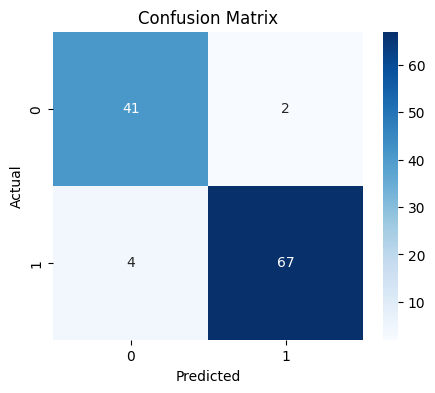

In [ ]:
cm = confusion_matrix(y_test, lda_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            cmap='Blues',
            fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(y_test, lda_pred))

              precision    recall  f1-score   support

           0       0.91      0.95      0.93        43
           1       0.97      0.94      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



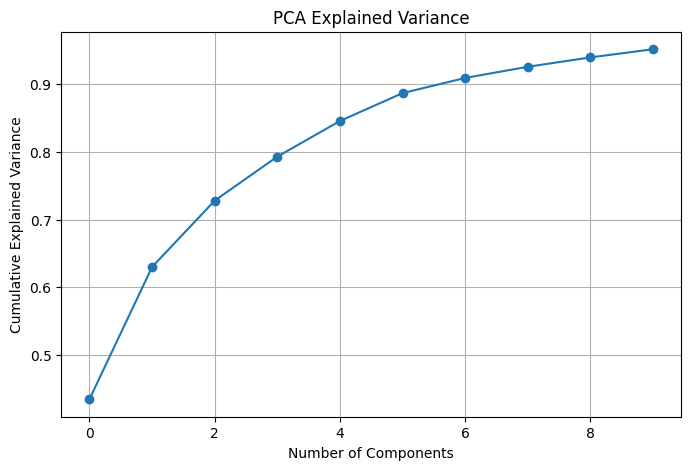

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(np.cumsum(pca.explained_variance_ratio_),
         marker='o')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.grid(True)
plt.show()

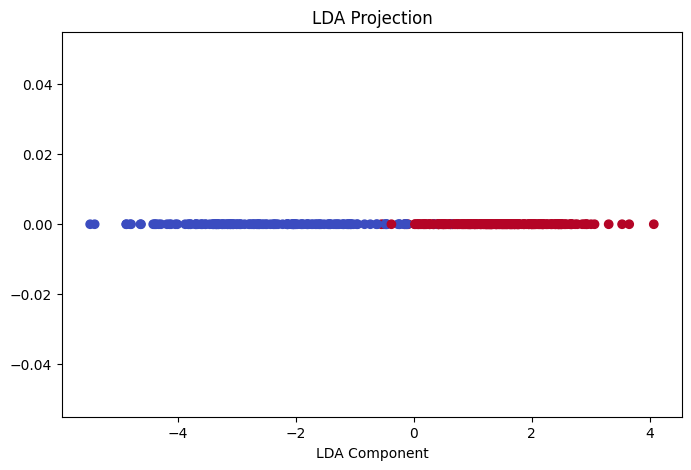

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    X_train_lda,
    np.zeros_like(X_train_lda),
    c=y_train,
    cmap='coolwarm'
)

plt.xlabel("LDA Component")
plt.title("LDA Projection")
plt.show()

In [ ]:
print("Accuracy Comparison")
print("--------------------------")
print("Baseline :", accuracy_score(y_test, y_pred))
print("PCA      :", accuracy_score(y_test, pca_pred))
print("LDA      :", accuracy_score(y_test, lda_pred))

Accuracy Comparison
--------------------------
Baseline : 0.9649122807017544
PCA      : 0.9473684210526315
LDA      : 0.9473684210526315
